In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

#BASE_PATH = "/content/drive/MyDrive/Data607_Project"


In [2]:
#import sys
#!{sys.executable} -m pip install -r requirements.txt --extra-index-url https://download.pytorch.org/whl/cu128 -v
!pip install numpy==1.26.4


   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
    --------------------------------------- 0.3/15.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.5 MB 1.5 MB/s eta 0:00:10
   -- ------------------------------------- 0.8/15.5 MB 1.6 MB/s eta 0:00:10
   --- ------------------------------------ 1.3/15.5 MB 1.7 MB/s eta 0:00:09
   ---- ----------------------------------- 1.8/15.5 MB 1.8 MB/s eta 0:00:08
   ----- ---------------------------------- 2.1/15.5 MB 1.9 MB/s eta 0:00:08
   ------ --------------------------------- 2.6/15.5 MB 1.9 MB/s eta 0:00:07
   -------- ------------------------------- 3.1/15.5 MB 2.0 MB/s eta 0:00:07
   ---------- ----------------------------- 3.9/15.5 MB 2.1 MB/s eta 0:00:06
   ----------- ---------------------------- 4.5/15.5 MB 2.2 MB/s eta 0:00:05
   ------------- -------------------------- 5.2/15.5 MB 2.3 MB/s eta 0:00:05
   --------------- ------------------------ 6.0/15.5 MB 2.4 MB/s eta 0:00:04
   ----------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
llama-index-readers-file 0.5.6 requires pandas<3,>=2.0.0, but you have pandas 3.0.2 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.2 which is incompatible.
streamlit 1.37.1 requires tenacity<9,>=8.1.0, but you have tenacity 9.1.4 which is incompatible.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import torchvision
import torch
from sklearn.model_selection import train_test_split
import os
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import torch.optim as optim

L:\code\python\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
L:\code\python\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [5]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "No GPU detected")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4070 Ti SUPER


In [6]:
#labeldf = pd.read_csv('/content/drive/MyDrive/Data607_Project/dataset_labels.csv')
labeldf = pd.read_csv('dataset_labels.csv')
classes = sorted(labeldf['species_common_name'].unique())  # ensures consistent ordering
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

fulltrain_X, test_X, fulltrain_y, test_y = train_test_split(labeldf.drop('species_common_name', axis=1), labeldf['species_common_name'], test_size=0.2, random_state=42)
train_X, val_X, train_y, val_y = train_test_split(fulltrain_X, fulltrain_y, test_size=0.2, random_state=42)

# Map string labels to integer indices
train_y = train_y.map(class_to_idx).reset_index(drop=True)
val_y   = val_y.map(class_to_idx).reset_index(drop=True)
test_y  = test_y.map(class_to_idx).reset_index(drop=True)

In [7]:
#### Get images into df
#ex: /content/drive/MyDrive/Data607_Project/all_images/31553939.jpg
input_folder = "resized_images/"

#imgs_train_paths = input_folder + train_X['filepath'].str[49:]
#imgs_val_paths = input_folder + val_X['filepath'].str[49:]
#imgs_test_paths = input_folder + test_X['filepath'].str[49:]


#input_folder = "/content/drive/MyDrive/Data607_Project/resized_images/"

imgs_train_paths = train_X["image_id"].astype(str).apply(lambda x: input_folder + x + ".jpg")
imgs_val_paths = val_X["image_id"].astype(str).apply(lambda x: input_folder + x + ".jpg")
imgs_test_paths = test_X["image_id"].astype(str).apply(lambda x: input_folder + x + ".jpg")

#imgs_train_paths = train_X['filepath'].str[39:]
#imgs_val_paths = val_X['filepath'].str[39:]
#imgs_test_paths = test_X['filepath'].str[39:]


In [8]:
class PreloadedImageDataset(Dataset):
    def __init__(self, paths, labels, transform=None, resize=(256, 256)):
        # Keep original labels
        self.labels = labels.reset_index(drop=True)
        self.transform = transform

        # Preload all images into memory
        self.images = []

        for path in paths.reset_index(drop=True):
            img = Image.open(path)

            # Flatten alpha channel if RGBA
            if img.mode == 'RGBA':
                background = Image.new('RGB', img.size, (255, 255, 255))
                background.paste(img, mask=img.split()[3])
                img = background

            # Convert grayscale or CMYK to RGB
            elif img.mode in ['L', 'CMYK']:
                img = img.convert('RGB')
            else:
                img = img.convert('RGB')

            # Resize once
            img = img.resize(resize, Image.BILINEAR)

            # Convert to float32 numpy array 0-1
            img = np.array(img).astype('float32') / 255.0

            self.images.append(img)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        # Convert label to torch.LongTensor
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(int(label), dtype=torch.long)

        if self.transform:
            img = self.transform(image=img)['image']

        return img, label



---





---



#VIT

##Load the ViT model

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
from torchvision import models
num_classes = len(classes)
vit_pretrained_model = models.vit_b_16(weights = models.ViT_B_16_Weights.IMAGENET1K_V1)
num_features = vit_pretrained_model.heads.head.in_features
print("Num features into head:", num_features)
vit_pretrained_model.heads.head = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)
vit_pretrained_model = vit_pretrained_model.to(device)

Num features into head: 768


##Transform

In [16]:
train_transform = A.Compose([
    # Geometric transforms
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=25, p=0.5),           # Slightly smaller rotation to reduce interpolation cost
    A.Affine(scale=(0.9, 1.1), p=0.5),   # Mild scaling instead of 0.8–1.2

    # Color & texture
    A.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05,
        p=0.5
    ),
    #
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),  # Keep blur, but lower probability

    # Optional: Add light fog/shadow occasionally using probabilistic wrapper
    # Only enable on a subset of batches or images
    A.RandomShadow(shadow_roi=(0,0,1,1), p=0.05),
    A.RandomFog(fog_coef_range=(0.1,0.2), p=0.05),

    # Normalize & convert to tensor
    #A.Normalize(mean=[0.485, 0.456, 0.406],
    #            std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(224, 224),
    #A.Normalize(mean=[0.485, 0.456, 0.406],
    #            std=[0.229, 0.224, 0.225]), # Means and Stds of imagenet dataset \cite{https://copyprogramming.com/howto/why-pytorch-officially-use-mean-0-485-0-456-0-406-and-std-0-229-0-224-0-225-to-normalize-images}
    ToTensorV2()
])

##Create Datasets & DataLoader


In [18]:
train_dataset = PreloadedImageDataset(imgs_train_paths, train_y, transform=train_transform)
val_dataset   = PreloadedImageDataset(imgs_val_paths,   val_y,   transform=val_transform)
test_dataset  = PreloadedImageDataset(imgs_test_paths,  test_y,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

##Loss Function & Optimizer

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    vit_pretrained_model.parameters(),
    lr=3e-5,
    weight_decay=1e-2
)

##Test Run

In [22]:
vit_pretrained_model.eval()  # evaluation mode (disables dropout)
with torch.no_grad():
    images, labels = next(iter(train_loader))  # grab one batch
    images = images.to(device)
    labels = labels.to(device)

    outputs = vit_pretrained_model(images)
    print("Output shape:", outputs.shape)  # should be (batch_size, num_classes)
    print("Sample outputs:", outputs[0])   # first image logits
    preds = torch.argmax(outputs, dim=1)
print("Predictions:", preds)
print("True labels:", labels)
vit_pretrained_model.train()
print('Test Complete')

Output shape: torch.Size([32, 6])
Sample outputs: tensor([-0.2712, -0.1157,  0.0700,  0.0894, -0.2295, -0.0796], device='cuda:0')
Predictions: tensor([3, 5, 3, 5, 0, 3, 3, 3, 3, 3, 2, 2, 2, 2, 1, 3, 3, 3, 3, 5, 3, 3, 1, 2,
        2, 3, 3, 2, 0, 0, 1, 2], device='cuda:0')
True labels: tensor([4, 2, 1, 3, 2, 2, 1, 4, 0, 3, 3, 4, 2, 3, 3, 5, 3, 4, 3, 3, 0, 0, 1, 0,
        5, 0, 1, 1, 5, 2, 4, 5], device='cuda:0')
Test Complete


##Evaluation Function

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, dataloader, device, criterion):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro')
    recall = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, acc, precision, recall, f1, all_labels, all_preds

In [25]:
import copy

num_epochs = 30
head_only_epochs = 10  # train only the head for first 5 epochs

# Early stopping settings
patience = 6
min_delta = 0.001
best_val_loss = float("inf")
best_epoch = 0
epochs_no_improve = 0

# Save best model weights
best_model_wts = copy.deepcopy(vit_pretrained_model.state_dict())

# History
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []
val_f1_history = []
lr_history = []

for epoch in range(num_epochs):

    # ===== Stage 1: freeze backbone at start =====
    if epoch == 0:
        for param in vit_pretrained_model.parameters():
            param.requires_grad = False

        for param in vit_pretrained_model.heads.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            vit_pretrained_model.heads.parameters(),
            lr=5e-3,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )

    # ===== Stage 2: unfreeze full model after head-only training =====
    if epoch == head_only_epochs:
        vit_pretrained_model.train()

        for param in vit_pretrained_model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            vit_pretrained_model.parameters(),
            lr=1e-4,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )

    # ===== TRAINING =====
    vit_pretrained_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = vit_pretrained_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # total loss across all samples
        running_loss += loss.item() * images.size(0)

        # training accuracy
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = running_loss / total_train
    train_acc = correct_train / total_train

    # ===== VALIDATION =====
    val_loss, val_acc, _, _, val_f1, _, _ = evaluate_model(
        vit_pretrained_model, val_loader, device, criterion
    )

    # ===== UPDATE LR =====
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ===== STORE HISTORY =====
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)
    val_f1_history.append(val_f1)
    lr_history.append(current_lr)

    # ===== PRINT EPOCH RESULTS =====
    print(
        f"Epoch {epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    # ===== EARLY STOPPING CHECK =====
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_no_improve = 0

        best_model_wts = copy.deepcopy(vit_pretrained_model.state_dict())
        torch.save(best_model_wts, "best_vit_model.pt")

        print("  -> Validation improved. Model saved.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement ({epochs_no_improve}/{patience})")

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}.")
        break

# ===== FINAL TEST EVALUATION =====
test_loss, test_acc, test_precision, test_recall, test_f1, all_labels, all_preds = evaluate_model(
    vit_pretrained_model, test_loader, device, criterion
)

print(
    f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
    f"Test Precision: {test_precision:.4f} | Test Recall: {test_recall:.4f} | Test F1: {test_f1:.4f}"
)


Epoch 001 | Train Loss: 1.2903 | Train Acc: 0.5035 | Val Loss: 0.9897 | Val Acc: 0.5938 | LR: 0.004986
  -> Validation improved. Model saved.
Epoch 002 | Train Loss: 1.0161 | Train Acc: 0.6319 | Val Loss: 0.9259 | Val Acc: 0.6424 | LR: 0.004945
  -> Validation improved. Model saved.
Epoch 003 | Train Loss: 0.8994 | Train Acc: 0.6649 | Val Loss: 0.8783 | Val Acc: 0.6562 | LR: 0.004878
  -> Validation improved. Model saved.
Epoch 004 | Train Loss: 0.9057 | Train Acc: 0.6389 | Val Loss: 0.8287 | Val Acc: 0.6944 | LR: 0.004784
  -> Validation improved. Model saved.
Epoch 005 | Train Loss: 0.8463 | Train Acc: 0.7005 | Val Loss: 0.8166 | Val Acc: 0.6875 | LR: 0.004665
  -> Validation improved. Model saved.
Epoch 006 | Train Loss: 0.7715 | Train Acc: 0.7283 | Val Loss: 0.8444 | Val Acc: 0.6840 | LR: 0.004523
  -> No improvement (1/6)
Epoch 007 | Train Loss: 0.8152 | Train Acc: 0.7040 | Val Loss: 0.7985 | Val Acc: 0.6806 | LR: 0.004358
  -> Validation improved. Model saved.
Epoch 008 | Train L


Best model from epoch 12 with val loss 0.5909
Test Loss: 0.6202 | Test Acc: 0.7806 | Test Precision: 0.7772 | Test Recall: 0.7794 | Test F1: 0.7757


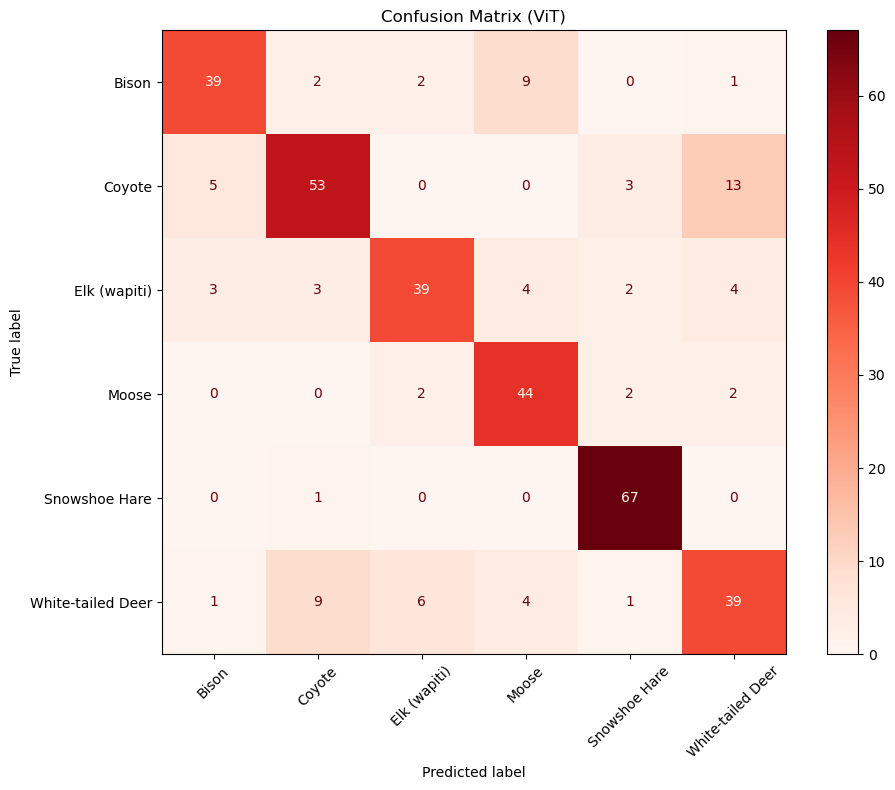

                   precision    recall  f1-score   support

            Bison       0.81      0.74      0.77        53
           Coyote       0.78      0.72      0.75        74
     Elk (wapiti)       0.80      0.71      0.75        55
            Moose       0.72      0.88      0.79        50
    Snowshoe Hare       0.89      0.99      0.94        68
White-tailed Deer       0.66      0.65      0.66        60

         accuracy                           0.78       360
        macro avg       0.78      0.78      0.78       360
     weighted avg       0.78      0.78      0.78       360



In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# LOAD BEST MODEL
vit_pretrained_model.load_state_dict(best_model_wts)

print(f"\nBest model from epoch {best_epoch} with val loss {best_val_loss:.4f}")

# FINAL TEST EVALUATION
test_loss, test_acc, test_precision, test_recall, test_f1, all_labels, all_preds = evaluate_model(
    vit_pretrained_model, test_loader, device, criterion
)

print(
    f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | "
    f"Test Precision: {test_precision:.4f} | Test Recall: {test_recall:.4f} | Test F1: {test_f1:.4f}"
)

# CONFUSION MATRIX
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Reds', ax=ax, xticks_rotation=45)

plt.title("Confusion Matrix (ViT)")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=classes))


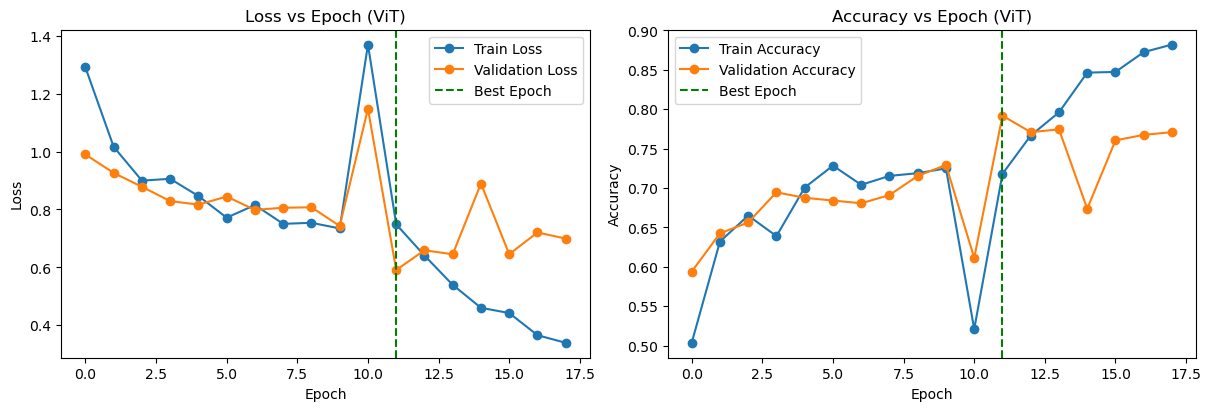

In [27]:
# TRAINING CURVES
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# ----- LOSS -----
axes[0].plot(train_loss_history, marker="o", label="Train Loss")
axes[0].plot(val_loss_history, marker="o", label="Validation Loss")
axes[0].axvline(best_epoch - 1, color='green', linestyle='--', label='Best Epoch')

axes[0].set_title("Loss vs Epoch (ViT)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()


# ----- ACCURACY -----
axes[1].plot(train_acc_history, marker="o", label="Train Accuracy")
axes[1].plot(val_acc_history, marker="o", label="Validation Accuracy")
axes[1].axvline(best_epoch - 1, color='green', linestyle='--', label='Best Epoch')

axes[1].set_title("Accuracy vs Epoch (ViT)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.show()

In [28]:
liam_image_path = "/content/drive/MyDrive/Data607_Project/resized_liam_images/bison.jpg"

# load image
liam_image = Image.open(liam_image_path).convert("RGB")

# apply Albumentations transform
liam_image = val_transform(image=np.array(liam_image))["image"]

# make sure tensor is float
liam_image = liam_image.float()

# add batch dimension
liam_image = liam_image.unsqueeze(0).to(device)

# predict
vit_pretrained_model.eval()
with torch.no_grad():
    outputs = vit_pretrained_model(liam_image)
    pred = torch.argmax(outputs, dim=1).item()

print("Prediction:", classes[pred])

# show image
plt.imshow(Image.open(liam_image_path))
plt.title(f"Prediction: {classes[pred]}")
plt.axis("off")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\content\\drive\\MyDrive\\Data607_Project\\resized_liam_images\\bison.jpg'